### คำอธิบาย: ตั้งค่าพื้นฐาน
- นำเข้าไลบรารีที่ใช้วิเคราะห์ข้อมูลและทำกราฟ
- ตั้งค่าสไตล์กราฟและขนาดรูปให้สม่ำเสมอ
- ดูยังไง: เซลล์นี้ไม่มี output หากรันแล้วกราฟถัดไปมีสไตล์เดียวกันแปลว่าใช้ได้

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

### คำอธิบาย: โหลดและรวมข้อมูล
- อ่านไฟล์ข้อมูล 5 กลุ่มจากโฟลเดอร์ data
- รวมทั้งหมดเป็น DataFrame เดียวชื่อ `df`
- ดูยังไง: ไปดูผลในเซลล์ที่พิมพ์ `df.shape` และ `df.head()` เพื่อยืนยันจำนวนแถว/คอลัมน์

In [2]:
df1 = pd.read_csv("../data/FOOD-DATA-GROUP1.csv")
df2 = pd.read_csv("../data/FOOD-DATA-GROUP2.csv")
df3 = pd.read_csv("../data/FOOD-DATA-GROUP3.csv")
df4 = pd.read_csv("../data/FOOD-DATA-GROUP4.csv")
df5 = pd.read_csv("../data/FOOD-DATA-GROUP5.csv")

df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

### คำอธิบาย: ลบคอลัมน์ที่ไม่จำเป็น
- ตัดคอลัมน์ index ที่ถูกบันทึกซ้ำ เช่น `Unnamed: 0`
- ใช้ `errors="ignore"` เพื่อไม่ให้พังถ้าไม่มีคอลัมน์นั้น
- ดูยังไง: ตรวจ `df.columns` หรือดู `df.info()` ว่าไม่มีคอลัมน์ดังกล่าว

In [3]:
df = df.drop(columns=["Unnamed: 0","Unnamed: 0.1"], errors="ignore")

### คำอธิบาย: สำรวจภาพรวมข้อมูล
- แสดงขนาดข้อมูล ตัวอย่างแถวแรก ชนิดข้อมูล และสถิติเบื้องต้น
- ตรวจจำนวนค่าว่างของแต่ละคอลัมน์
- ดูยังไง: `shape` บอกจำนวนแถว/คอลัมน์, `head()` ดูตัวอย่าง, `info()` ดูชนิด, `describe()` ดูค่าเฉลี่ย/กระจาย, และตารางค่าว่าง

In [4]:
print("Shape:", df.shape)

df.head()
df.info()
df.describe()
df.isnull().sum().sort_values(ascending=False)

Shape: (2395, 35)
<class 'pandas.DataFrame'>
RangeIndex: 2395 entries, 0 to 2394
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   food                  2395 non-null   str    
 1   Caloric Value         2395 non-null   int64  
 2   Fat                   2395 non-null   float64
 3   Saturated Fats        2395 non-null   float64
 4   Monounsaturated Fats  2395 non-null   float64
 5   Polyunsaturated Fats  2395 non-null   float64
 6   Carbohydrates         2395 non-null   float64
 7   Sugars                2395 non-null   float64
 8   Protein               2395 non-null   float64
 9   Dietary Fiber         2395 non-null   float64
 10  Cholesterol           2395 non-null   float64
 11  Sodium                2395 non-null   float64
 12  Water                 2395 non-null   float64
 13  Vitamin A             2395 non-null   float64
 14  Vitamin B1            2395 non-null   float64
 15  Vitamin B11   

food                    0
Copper                  0
Vitamin B6              0
Vitamin C               0
Vitamin D               0
Vitamin E               0
Vitamin K               0
Calcium                 0
Iron                    0
Vitamin B3              0
Magnesium               0
Manganese               0
Phosphorus              0
Potassium               0
Selenium                0
Zinc                    0
Vitamin B5              0
Vitamin B2              0
Caloric Value           0
Protein                 0
Fat                     0
Saturated Fats          0
Monounsaturated Fats    0
Polyunsaturated Fats    0
Carbohydrates           0
Sugars                  0
Dietary Fiber           0
Vitamin B12             0
Cholesterol             0
Sodium                  0
Water                   0
Vitamin A               0
Vitamin B1              0
Vitamin B11             0
Nutrition Density       0
dtype: int64

### คำอธิบาย: แจกแจงการกระจายสารอาหารหลัก
- สร้างฮิสโตแกรมของแคลอรี ไขมัน คาร์บ และโปรตีน
- ช่วยดูช่วงค่าที่พบมากและการเบ้ของข้อมูล
- ดูยังไง: ดูยอดแท่งสูงสุดเพื่อรู้ช่วงค่าที่พบบ่อย และดูการลากหางเพื่อเห็น outlier

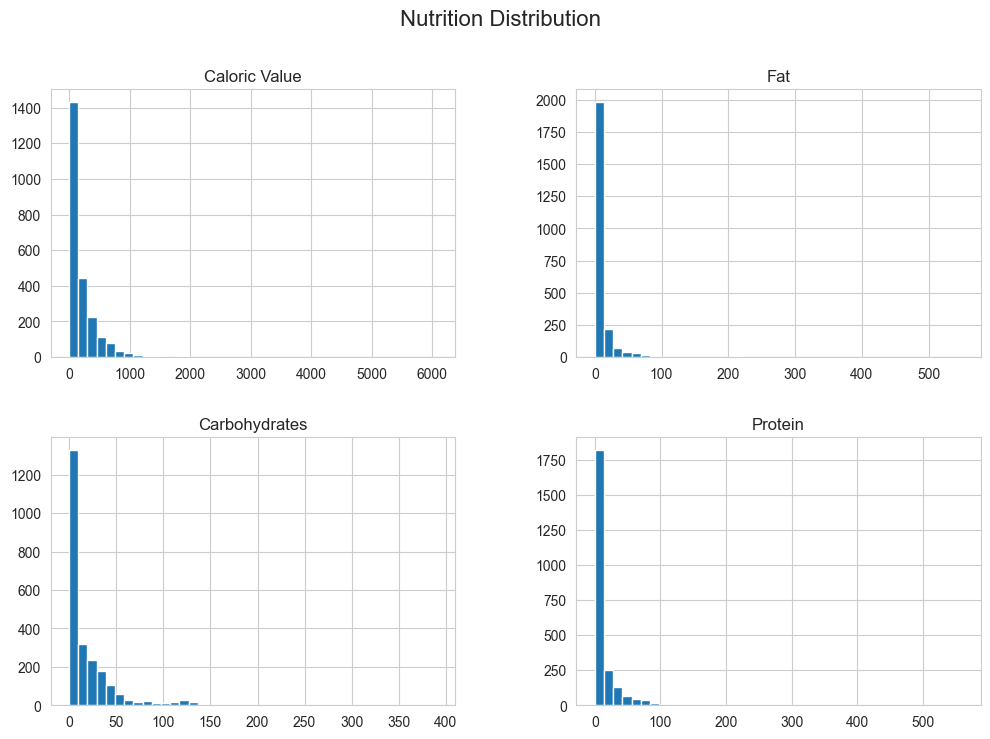

In [5]:
nutrients = ["Caloric Value","Fat","Carbohydrates","Protein"]

df[nutrients].hist(bins=40, figsize=(12,8))
plt.suptitle("Nutrition Distribution", fontsize=16)
plt.show()

### คำอธิบาย: สรุปผลเบื้องต้นจากกราฟ
- สรุปแนวโน้มที่เห็นจากฮิสโตแกรมด้านบน
- ดูยังไง: เทียบข้อความสรุปกับช่วงค่าที่แท่งกระจุกและการกระจายของโปรตีน

Most foods fall between 100–400 calories.
Protein distribution is skewed with a few high-protein foods.

### คำอธิบาย: อาหารแคลอรีสูงสุด 10 อันดับ
- เรียงข้อมูลตามแคลอรีจากมากไปน้อย แล้วเลือก 10 รายการ
- วาดกราฟแท่งเพื่อเปรียบเทียบ
- ดูยังไง: แท่งยาวสุดคือแคลอรีสูงสุด และดูชื่ออาหารที่แกน Y

/var/folders/sm/0bqg1ksx1y1gflx1mn01vd3c0000gn/T/ipykernel_84315/2213118835.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cal,


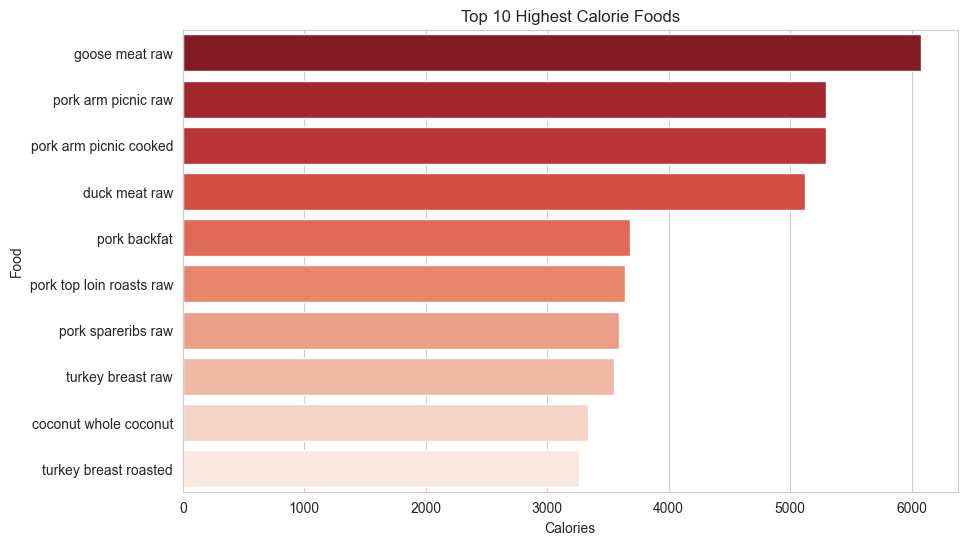

In [6]:
top_cal = df.sort_values("Caloric Value", ascending=False).head(10)

sns.barplot(data=top_cal,
            x="Caloric Value",
            y="food",
            palette="Reds_r")

plt.title("Top 10 Highest Calorie Foods")
plt.xlabel("Calories")
plt.ylabel("Food")
plt.show()

### คำอธิบาย: อาหารโปรตีนสูงสุด 10 อันดับ
- เรียงตามโปรตีนและแสดงกราฟแท่ง
- ช่วยเห็นอาหารที่โปรตีนสูงเด่นชัด
- ดูยังไง: ดูความยาวแท่งและชื่ออาหารด้านซ้าย

/var/folders/sm/0bqg1ksx1y1gflx1mn01vd3c0000gn/T/ipykernel_84315/3787736129.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_protein,


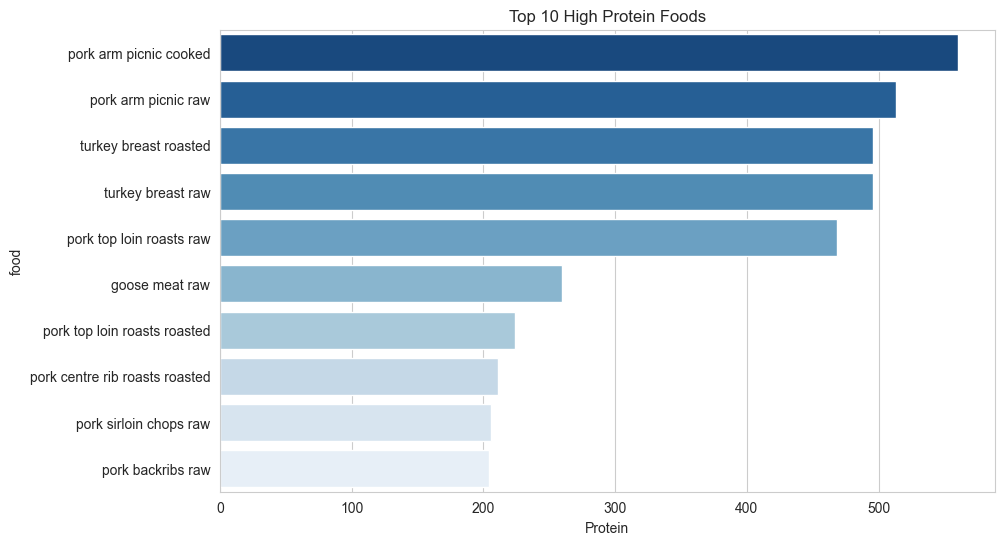

In [7]:
top_protein = df.sort_values("Protein", ascending=False).head(10)

sns.barplot(data=top_protein,
            x="Protein",
            y="food",
            palette="Blues_r")

plt.title("Top 10 High Protein Foods")
plt.show()

### คำอธิบาย: ความสัมพันธ์ไขมันกับแคลอรี
- สร้าง scatter plot เพื่อดูแนวโน้มร่วม
- ถ้าจุดมีแนวโน้มขึ้นขวา แปลว่าไขมันสูงสัมพันธ์กับแคลอรีสูง
- ดูยังไง: มองรูปแบบกลุ่มจุดและ outlier ที่กระโดดสูง

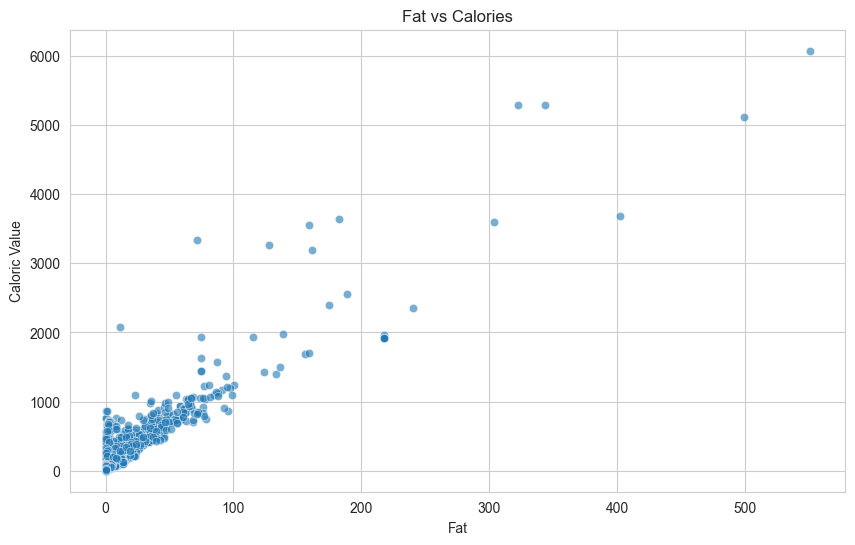

In [8]:
sns.scatterplot(data=df,
                x="Fat",
                y="Caloric Value",
                alpha=0.6)

plt.title("Fat vs Calories")
plt.show()

### คำอธิบาย: สหสัมพันธ์ของสารอาหาร
- คำนวณค่าสหสัมพันธ์ของตัวแปรเชิงตัวเลข
- แสดงเป็น heatmap เพื่อดูความสัมพันธ์เชิงบวก/ลบ
- ดูยังไง: สีเข้มคือความสัมพันธ์แรง และดูคู่ที่เด่นที่สุด

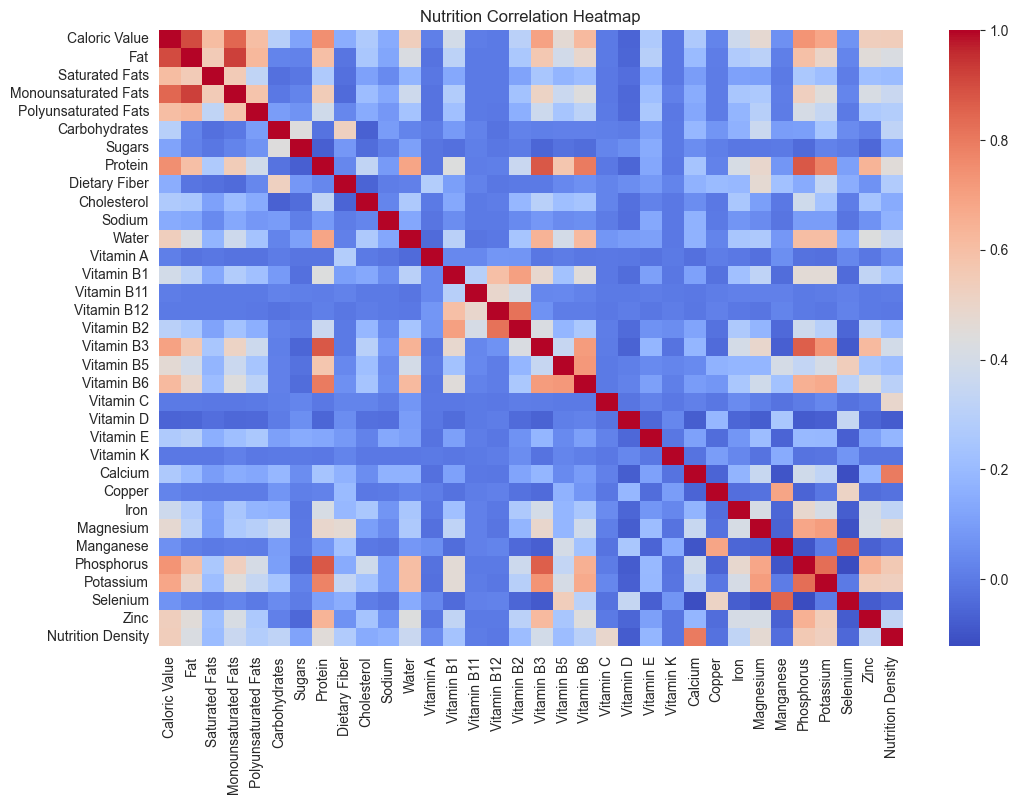

In [9]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(corr,
            cmap="coolwarm",
            annot=False)

plt.title("Nutrition Correlation Heatmap")
plt.show()

### คำอธิบาย: น้ำตาลกับคาร์โบไฮเดรต
- ตรวจสอบว่าน้ำตาลสัมพันธ์กับคาร์โบไฮเดรตมากแค่ไหน
- ใช้ scatter plot เพื่อดูแนวโน้ม
- ดูยังไง: ถ้าจุดเรียงเป็นแนวขึ้น แปลว่าน้ำตาลเพิ่มตามคาร์บ

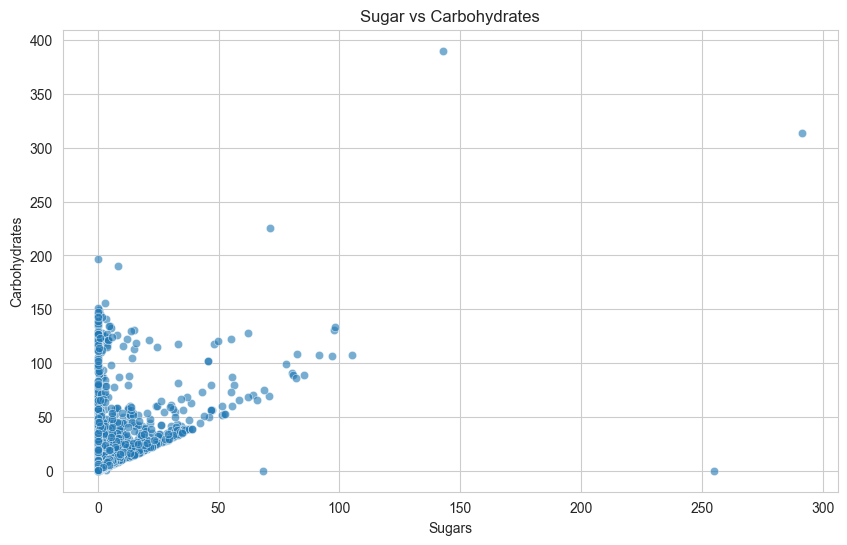

In [10]:
sns.scatterplot(data=df,
                x="Sugars",
                y="Carbohydrates",
                alpha=0.6)

plt.title("Sugar vs Carbohydrates")
plt.show()

### คำอธิบาย: รวมสารอาหารหลัก
- สร้างคอลัมน์ `Macro_Total` จาก Fat + Carbohydrates + Protein
- ใช้เป็นตัวชี้วัดความหนาแน่นสารอาหารหลัก
- ดูยังไง: ลองดู `df[['Macro_Total']].head()` เพื่อเช็กว่าคอลัมน์ถูกสร้าง

In [11]:
df["Macro_Total"] = (
    df["Fat"] +
    df["Carbohydrates"] +
    df["Protein"]
)

### คำอธิบาย: การกระจายของค่า Macro_Total
- ดูการกระจายของผลรวมสารอาหารหลัก
- ช่วยระบุว่าค่าโดยมากอยู่ช่วงไหน
- ดูยังไง: ดูยอดแท่งสูงสุดและการกระจายด้านขวาซ้าย

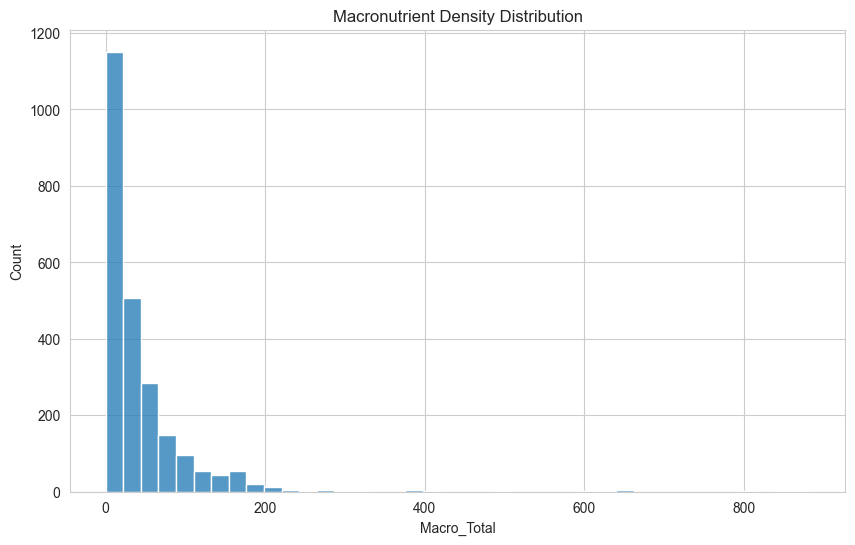

In [12]:
sns.histplot(df["Macro_Total"], bins=40)

plt.title("Macronutrient Density Distribution")
plt.show()

### คำอธิบาย: บทสรุปภาพรวม
- รวมข้อค้นพบสำคัญจากการวิเคราะห์ก่อนหน้า
- ดูยังไง: ไล่ตรวจแต่ละข้อแล้วกลับไปดูกราฟที่เกี่ยวข้องว่ารองรับข้อสรุปหรือไม่

Key Insights

1. Most foods contain between 100–400 calories.

2. Fat has the strongest relationship with calorie value.

3. High-protein foods also tend to have higher calorie levels.

4. Sugar strongly correlates with carbohydrate content.

5. A small number of foods contain extremely high calorie values, which may be considered outliers.

### คำอธิบาย: ความสัมพันธ์แบบคู่
- สร้าง pairplot สำหรับแคลอรี ไขมัน โปรตีน คาร์บ
- ช่วยเห็นรูปแบบความสัมพันธ์และการกระจายพร้อมกัน
- ดูยังไง: ช่องทแยงคือการกระจายตัวแปรเดี่ยว ช่องอื่นดูแนวโน้มจุด

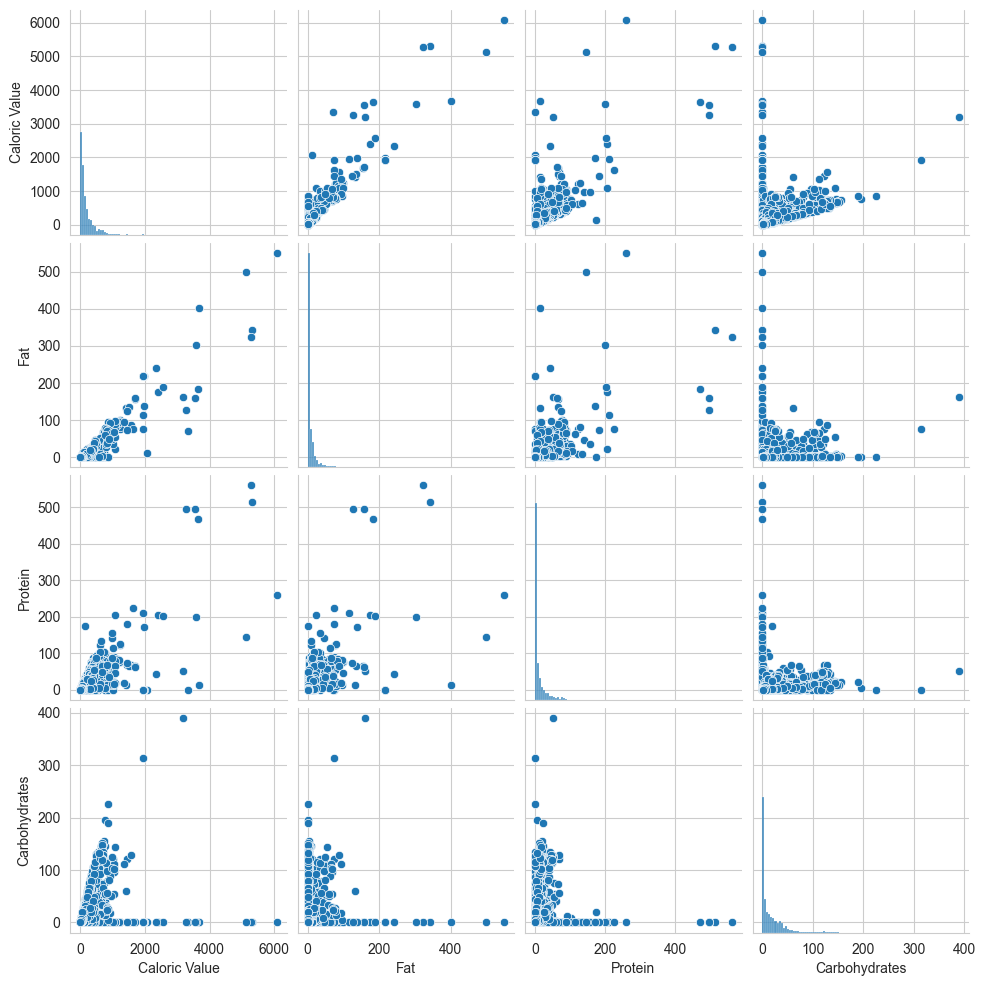

In [13]:
sns.pairplot(df[["Caloric Value","Fat","Protein","Carbohydrates"]])

### คำอธิบาย: เลือกคอลัมน์สำคัญ
- กำหนดชุดคุณลักษณะที่ต้องใช้ต่อในงานวิเคราะห์
- ลดข้อมูลให้เหลือเฉพาะสารอาหารที่สนใจ
- ดูยังไง: ตรวจ `df_selected.head()` และ `df_selected.columns` ว่าครบตามรายการ

In [14]:
selected_columns = [
    "food",
    "Caloric Value",
    "Fat",
    "Carbohydrates",
    "Protein",
    "Sugars",
    "Dietary Fiber",
    "Cholesterol",
    "Sodium",
    "Vitamin B12",
    "Zinc",
    "Nutrition Density"
]

df_selected = df[selected_columns]

### คำอธิบาย: ตรวจตัวอย่างข้อมูลหลังคัดเลือก
- แสดงแถวแรกของ `df_selected`
- ใช้ยืนยันว่าชื่อคอลัมน์และค่าอยู่ในรูปแบบถูกต้อง
- ดูยังไง: ดู 5 แถวแรกและชื่อคอลัมน์

In [15]:
df_selected.head()

,food,Caloric Value,Fat,Carbohydrates,Protein,Sugars,Dietary Fiber,Cholesterol,Sodium,Vitamin B12,Zinc,Nutrition Density
0,cream cheese,51,5.0,0.8,0.9,0.500,0.0,14.6,0.016,0.092,0.039,7.070
1,neufchatel cheese,215,19.4,3.1,7.8,2.700,0.0,62.9,0.300,0.090,0.700,130.100
2,requeijao cremoso light catupiry,49,3.6,0.9,0.8,3.400,0.1,0.0,0.000,0.000,0.000,5.400
3,ricotta cheese,30,2.0,1.5,1.5,0.091,0.0,9.8,0.017,0.091,0.035,5.196
4,cream cheese low fat,30,2.3,1.2,1.2,0.900,0.0,8.1,0.046,0.049,0.053,27.007


### คำอธิบาย: ขนาดข้อมูลหลังคัดเลือก
- ดูจำนวนแถว/คอลัมน์ของข้อมูลที่เลือกแล้ว
- ใช้ตรวจว่าลดคอลัมน์ได้ตามที่ตั้งใจ
- ดูยังไง: ผลลัพธ์เป็น (แถว, คอลัมน์)

In [16]:
df_selected.shape

(2395, 12)

### คำอธิบาย: ตรวจค่าว่าง
- นับจำนวนค่าว่างต่อคอลัมน์
- ช่วยตัดสินใจว่าจะต้องทำการเติมค่าหรือไม่
- ดูยังไง: ถ้าทุกคอลัมน์เป็น 0 แสดงว่าไม่มี missing

In [17]:
df_selected.isnull().sum()

food                 0
Caloric Value        0
Fat                  0
Carbohydrates        0
Protein              0
Sugars               0
Dietary Fiber        0
Cholesterol          0
Sodium               0
Vitamin B12          0
Zinc                 0
Nutrition Density    0
dtype: int64

### คำอธิบาย: เหตุผลการเลือกข้อมูล
- อธิบายว่าทำไมเลือกคอลัมน์เหล่านี้เป็นตัวแทนสารอาหารหลัก
- ดูยังไง: ตรวจว่าแต่ละคอลัมน์ตอบโจทย์การวิเคราะห์ที่ต้องการ

### Data Selection

To focus on the most relevant nutritional information, a subset of columns was selected from the original dataset.

The selected features include:

- Caloric Value
- Fat
- Carbohydrates
- Protein
- Sugars
- Dietary Fiber
- Cholesterol
- Sodium
- Vitamin B12
- Zinc
- Nutrition Density

These features were chosen because they represent the most important macronutrients and micronutrients used in food nutrition analysis.

### คำอธิบาย: สหสัมพันธ์ของคอลัมน์ที่เลือก
- คำนวณ correlation เฉพาะสารอาหารที่สนใจ
- ช่วยหา feature ที่สัมพันธ์กันสูง
- ดูยังไง: สีเข้มและค่าใกล้ 1 หรือ -1 คือสัมพันธ์แรง

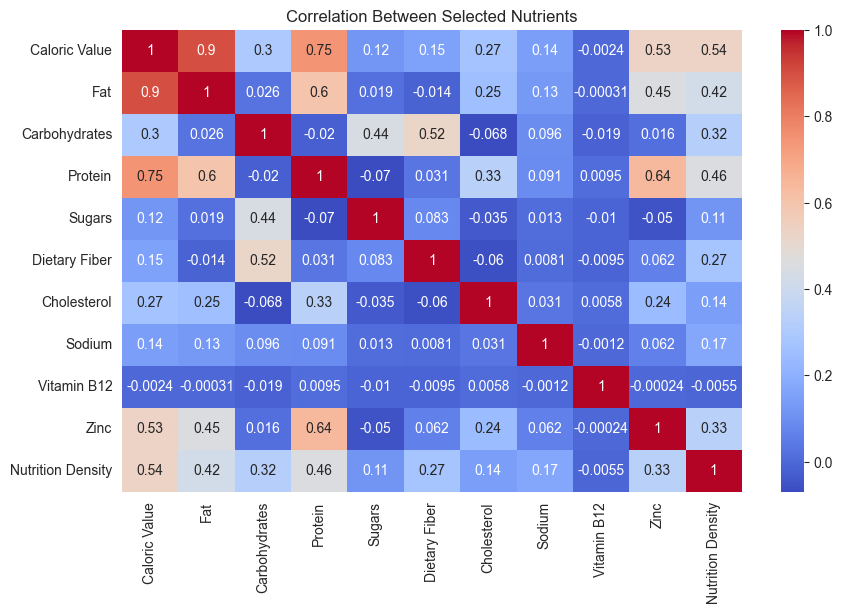

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    df_selected.drop(columns="food").corr(),
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation Between Selected Nutrients")
plt.show()

### คำอธิบาย: pairplot ของตัวแปรหลัก
- ดูความสัมพันธ์ระหว่างแคลอรี ไขมัน โปรตีน คาร์บ
- เหมาะสำหรับตรวจรูปแบบเชิงเส้นและ outlier
- ดูยังไง: จุดกระจุกเป็นแนวเดียวบอกความสัมพันธ์

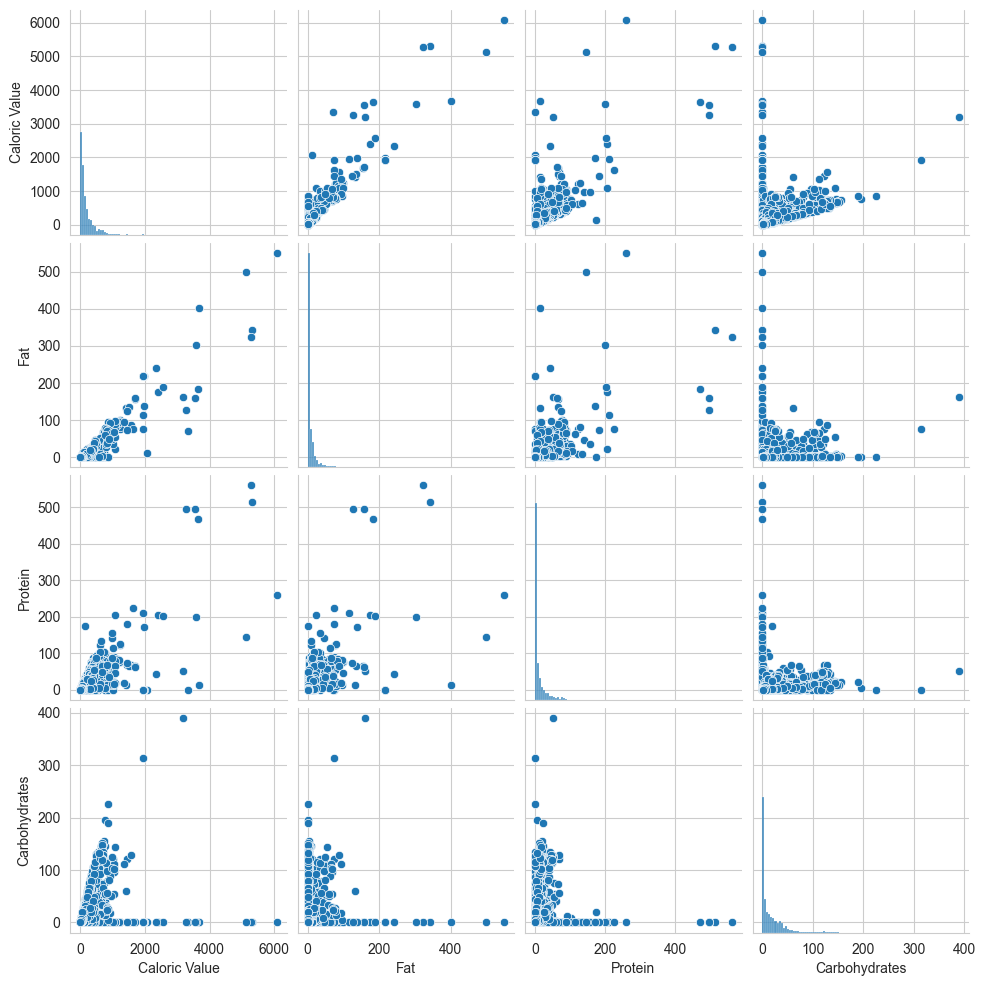

In [19]:
sns.pairplot(df_selected[[
"Caloric Value",
"Fat",
"Protein",
"Carbohydrates"
]])

### คำอธิบาย: ย้ำความสัมพันธ์ไขมัน-แคลอรี
- ใช้ข้อมูลที่คัดเลือกแล้วเพื่อดูแนวโน้ม
- มองความชันของกลุ่มจุดเป็นตัวชี้
- ดูยังไง: แนวขึ้นขวาคือสัมพันธ์เชิงบวก

Text(0.5, 1.0, 'Fat vs Calories')

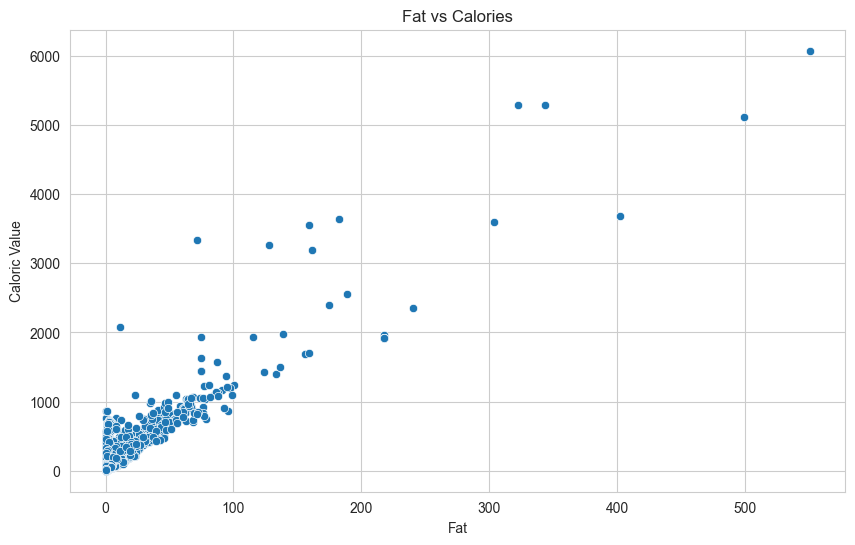

In [20]:
sns.scatterplot(
    data=df_selected,
    x="Fat",
    y="Caloric Value"
)

plt.title("Fat vs Calories")

### คำอธิบาย: พื้นที่บันทึกเพิ่มเติม
- ใช้สำหรับเพิ่มบันทึกผลลัพธ์หรือข้อสังเกตภายหลัง
- ดูยังไง: ถ้ามีการเพิ่มบันทึก ให้ตรวจว่าตรงกับกราฟ/ตารางที่อยู่ใกล้เคียง

### คำอธิบาย: ตรวจและลบข้อมูลซ้ำ
- นับจำนวนแถวที่ซ้ำ แล้วลบออกจาก `df_selected`
- ช่วยให้แต่ละอาหารไม่ถูกนับซ้ำ
- ดูยังไง: รัน `df_selected.duplicated().sum()` ก่อน/หลังเพื่อดูว่าลดลงหรือไม่

In [21]:
# Duplicate Data
df_selected.duplicated().sum()
df_selected = df_selected.drop_duplicates()

### คำอธิบาย: ผลการจัดการข้อมูลซ้ำ
- ยืนยันว่าได้ลบข้อมูลซ้ำออกแล้ว
- ดูยังไง: เปรียบเทียบจำนวนแถวก่อน/หลังลบเพื่อยืนยันการเปลี่ยนแปลง

Duplicate records were checked and removed to ensure that each food item appears only once in the dataset.

### คำอธิบาย: ตรวจชนิดข้อมูลและค่าติดลบ
- ดูชนิดข้อมูลของแต่ละคอลัมน์
- นับจำนวนค่าที่น้อยกว่า 0 ในคอลัมน์ตัวเลข
- ดูยังไง: ผล `dtypes` ต้องเป็นตัวเลขเหมาะสม และตารางค่าติดลบควรเป็น 0

In [22]:
# Invalid / Wrong Format
df_selected.dtypes
(df_selected.drop(columns="food") < 0).sum()

Caloric Value        0
Fat                  0
Carbohydrates        0
Protein              0
Sugars               0
Dietary Fiber        0
Cholesterol          0
Sodium               0
Vitamin B12          0
Zinc                 0
Nutrition Density    0
dtype: int64

### คำอธิบาย: ผลการตรวจชนิดข้อมูล
- สรุปว่ามีการตรวจชนิดข้อมูลและค่าที่ผิดปกติ
- ดูยังไง: ถ้าพบค่าติดลบหรือตัวอักษรในคอลัมน์ตัวเลข ต้องทำความสะอาดต่อ

Data types were verified and invalid values such as negative nutritional values were checked.

### คำอธิบาย: ตรวจความซ้ำซ้อนตามชื่ออาหาร
- นับจำนวนแถวต่อชื่อ `food` แล้วเรียงมากไปน้อย
- ช่วยหาอาหารที่มีหลายรายการผิดปกติ
- ดูยังไง: ถ้าบางชื่อมีจำนวนมากผิดปกติ อาจต้องตรวจซ้ำ

In [23]:
# Inconsistency Data
df_selected.groupby("food").size().sort_values(ascending=False).head()

food
abalone                      1
pork salami                  1
pork shoulder raw            1
pork sirloin chops cooked    1
pork sirloin chops raw       1
dtype: int64

### คำอธิบาย: ผลการตรวจความสอดคล้อง
- ยืนยันว่ารูปแบบชื่ออาหารและค่าทางโภชนาการสอดคล้องกัน
- ดูยังไง: ถ้าเห็นชื่อซ้ำแบบสะกดต่างกัน อาจต้องจัดมาตรฐานชื่อ

Consistency checks were performed to ensure that food names and nutritional values follow the same format across the dataset.

### คำอธิบาย: ตรวจค่าว่างอีกครั้ง
- นับค่าว่างใน `df_selected`
- ใช้ยืนยันก่อนขั้นตอนทำความสะอาดต่อ
- ดูยังไง: ค่า 0 ทุกคอลัมน์แปลว่าไม่มีค่าว่าง

In [24]:
# Missing Data
df_selected.isnull().sum()

food                 0
Caloric Value        0
Fat                  0
Carbohydrates        0
Protein              0
Sugars               0
Dietary Fiber        0
Cholesterol          0
Sodium               0
Vitamin B12          0
Zinc                 0
Nutrition Density    0
dtype: int64

### คำอธิบาย: ผลการตรวจค่าว่าง
- สรุปว่าไม่พบค่าว่างในข้อมูลชุดนี้
- ดูยังไง: ผลการนับค่าว่างก่อนหน้าเป็น 0 ทุกคอลัมน์

No missing values were found in the dataset, so no imputation was required.

### คำอธิบาย: มองหา outlier ด้วย boxplot
- วาด boxplot ของทุกคอลัมน์ตัวเลข
- จุดที่อยู่นอกหนวดคือ outlier
- ดูยังไง: มองจุดที่โดดไกลจากกล่องแต่ละตัวแปร

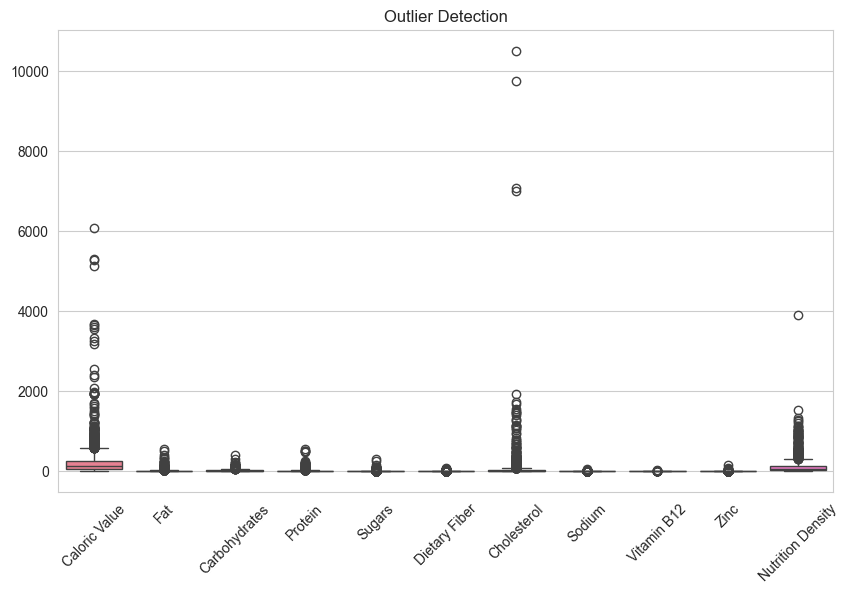

In [25]:
# Outlier Detection
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(data=df_selected.drop(columns="food"))

plt.xticks(rotation=45)
plt.title("Outlier Detection")
plt.show()


### คำอธิบาย: ลบ outlier ด้วย IQR
- คำนวณ Q1, Q3 และ IQR
- ลบแถวที่มีค่าหลุดนอกช่วง $[Q1-1.5*IQR, Q3+1.5*IQR]$
- ดูยังไง: เปรียบเทียบจำนวนแถวก่อน/หลังด้วย `df_selected.shape` และ `df_clean.shape`

In [26]:
# Remove outliers using IQR
Q1 = df_selected.drop(columns="food").quantile(0.25)
Q3 = df_selected.drop(columns="food").quantile(0.75)
IQR = Q3 - Q1

df_clean = df_selected[
    ~((df_selected.drop(columns="food") < (Q1 - 1.5 * IQR)) |
      (df_selected.drop(columns="food") > (Q3 + 1.5 * IQR)))
    .any(axis=1)
]